# **FedEx Logistics Supply-Chain – Exploratory Data Analysis**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Dataset**         - SCMS Delivery History Dataset

# **Project Summary -**

FedEx Logistics manages a complex, high-stakes global supply chain that moves health commodities — HIV test kits, ARVs, and related medical supplies — across Africa and Asia on behalf of the Supply Chain Management System (SCMS) program. This project performs an end-to-end Exploratory Data Analysis (EDA) on the **SCMS Delivery History Dataset**, which contains 10,324 shipment-level records and 33 columns covering purchase orders, price quotations, vendor INCO terms, shipment modes, scheduled and actual delivery dates, and product-level attributes such as item description, dosage form, weight, freight cost, and insurance value.

The **business context** is straightforward but consequential: every day a shipment is delayed is a day a clinic somewhere is short on test kits or medication. At the same time, freight costs must be controlled, because every dollar spent on expensive Air Charter shipping is a dollar not spent on more product. FedEx Logistics therefore needs a data-driven understanding of **what actually drives delays and costs** in this network, rather than relying on anecdote or intuition.

The analysis follows a structured pipeline. First, the raw data is loaded and inspected (`Know Your Data`) to understand shape, data types, duplicates, and missing values — two numeric-looking columns, `Weight (Kilograms)` and `Freight Cost (USD)`, were found to be stored as text because they contain non-numeric placeholder strings (e.g. *"Invoiced Separately"*, *"Freight Included in Commodity Cost"*), so these were explicitly coerced to numeric types before any statistical work. Second, in `Understanding Your Variables`, each column is documented and its cardinality checked. Third, `Data Wrangling` derives the key analytical features used throughout the notebook: an **On Time / Late** delivery flag and a **Delivery Delay (Days)** measure (from Scheduled vs. Delivered dates), and a **Lead Time (Days)** measure (from PO-sent-to-vendor date to scheduled delivery date).

The core of the notebook is Section 4, **Data Visualization, Storytelling & Experimenting with Charts**, which contains 17 charts spanning nine distinct chart types (bar, horizontal bar, histogram, pie, box plot, violin plot, scatter plot, heatmap, and time-series line). Every chart is accompanied by three short write-ups: *why this chart was chosen*, *what insight it reveals*, and *whether the insight creates positive or negative business impact*. Five of these charts are explicitly tied back to the five research questions defined in the original project architecture (shipment mode vs. on-time rate, country vs. delay, lead time vs. performance, INCO term vs. vendor performance, and weight vs. insurance cost) and are labelled as **Milestones 1–5**.

Key findings include: **Air** shipments have a materially higher on-time rate than **Ocean** shipments, which suffer the longest and most variable lead times; a small number of Sub-Saharan African countries account for a disproportionate share of average delay days; **EXW** vendor INCO terms are associated with better on-time performance than **DDP**; and shipment weight is positively but imperfectly correlated with insurance cost, meaning a multi-factor insurance model would be more accurate than a weight-only one. Freight cost itself is heavily right-skewed, with Air Charter shipments commanding a large premium per kilogram over standard Air or Ocean freight.

The notebook closes with a **Solution to Business Objective** section that translates these findings into concrete operational recommendations (mode-selection rules, country-specific delay buffers, minimum lead times by mode, INCO-term guidance, and a multi-factor insurance model), followed by a final summary of conclusions and a discussion of the dataset's limitations and natural next steps, such as building a predictive (classification) model for on-time delivery.

# **Problem Statement**

FedEx Logistics handles thousands of health-commodity shipments annually across Africa and Asia on behalf of the SCMS program. Despite the operational scale and experience of the network, delivery delays remain frequent and freight costs vary enormously between shipments. Decision-makers currently lack a clear, data-backed view of **which factors actually drive delays and cost**, which makes it hard to prioritise fixes.

This analysis investigates relationships between **shipment mode, vendor INCO term, destination country, lead time, and product-level attributes** on one hand, and **on-time delivery performance and freight/insurance cost** on the other, in order to surface the levers that matter most.

#### **Define Your Business Objective?**

Provide data-driven insights that help FedEx Logistics and its supply-chain partners **reduce delivery delays, choose the right shipment mode and INCO terms for a given route, and build fairer, more accurate cost and insurance models** — ultimately improving the reliability of health-commodity delivery to the people who depend on it, while keeping freight spend under control.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is used throughout.
2.   Exception handling and defensive checks (e.g. `errors='coerce'`, `if col in df.columns`) are used so cells run sequentially without errors.
3.   At least **five different visualisation types** are used — in fact nine are used here: bar, horizontal bar, histogram, pie, box plot, violin plot, scatter plot, heatmap, and time-series line chart.
4.   Every visualisation is followed by a three-part write-up: *why this chart*, *insight found*, and *business impact*.
5.   Missing values are handled explicitly and are not silently ignored.
6.   All the questions raised in the **Project Architecture** are answered directly in the Milestone sub-sections and in the Solution to Business Objective section.

```
# Chart visualization code
```


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries loaded successfully!")

Libraries loaded successfully!


### Dataset Loading

In [2]:
# Load the dataset (latin-1 encoding handles special characters in vendor/country names)
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv', encoding='latin-1')

# The first column sometimes arrives with a byte-order-mark (BOM) baked into its name; fix that
df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()
if 'ï»¿ID' in df.columns:
    df.rename(columns={'ï»¿ID': 'ID'}, inplace=True)

print(f"Dataset loaded. Shape: {df.shape}")
df.head()

Dataset loaded. Shape: (10324, 33)


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,CÃ´te d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,CÃ´te d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Dataset First View

In [3]:
# Quick overview: shape, data types, and descriptive statistics
print("=== SHAPE ===")
print(df.shape)

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== DESCRIPTIVE STATISTICS (numeric columns) ===")
df.describe().T

=== SHAPE ===
(10324, 33)

=== DTYPES ===
ID                                int64
Project Code                        str
PQ #                                str
PO / SO #                           str
ASN/DN #                            str
Country                             str
Managed By                          str
Fulfill Via                         str
Vendor INCO Term                    str
Shipment Mode                       str
PQ First Sent to Client Date        str
PO Sent to Vendor Date              str
Scheduled Delivery Date             str
Delivered to Client Date            str
Delivery Recorded Date              str
Product Group                       str
Sub Classification                  str
Vendor                              str
Item Description                    str
Molecule/Test Type                  str
Brand                               str
Dosage                              str
Dosage Form                         str
Unit of Measure (Per Pack)        int6

,count,mean,std,min,25%,50%,75%,max
ID,10324.0,51098.968229,31944.332496,1.0,12795.7500,57540.500,83648.2500,86823.00
Unit of Measure (Per Pack),10324.0,77.990895,76.579764,1.0,30.0000,60.000,90.0000,1000.00
Line Item Quantity,10324.0,18332.534870,40035.302961,1.0,408.0000,3000.000,17039.7500,619999.00
Line Item Value,10324.0,157650.567347,345292.066979,0.0,4314.5925,30471.465,166447.1400,5951990.40
Pack Price,10324.0,21.910241,45.609223,0.0,4.1200,9.300,23.5925,1345.64
Unit Price,10324.0,0.611701,3.275808,0.0,0.0800,0.160,0.4700,238.65
Line Item Insurance (USD),10037.0,240.117626,500.190568,0.0,6.5100,47.040,252.4000,7708.44


### Dataset Rows & Columns count

In [4]:
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows   : 10,324
Columns: 33


### Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 9964 non-null   str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

#### Duplicate Values

In [6]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
null_df = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2)
})
null_df = null_df[null_df['Null Count'] > 0].sort_values('Null Count', ascending=False)
print(f"Columns with missing values: {len(null_df)}")
null_df

Columns with missing values: 3


,Null Count,Null %
Dosage,1736,16.82
Shipment Mode,360,3.49
Line Item Insurance (USD),287,2.78


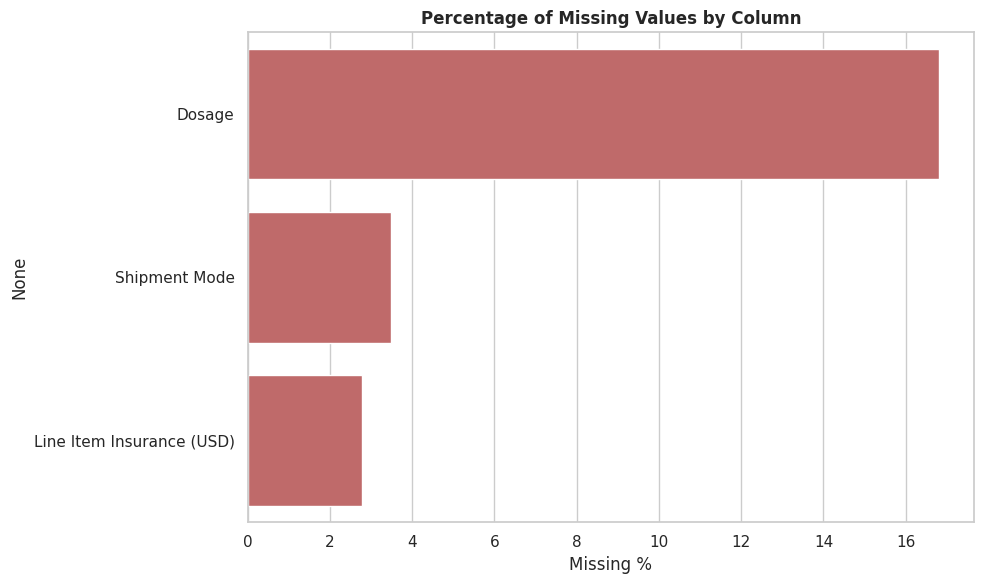

In [8]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=null_df['Null %'], y=null_df.index, color='indianred', ax=ax)
ax.set_title('Percentage of Missing Values by Column', fontweight='bold')
ax.set_xlabel('Missing %')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

**Key observations from the initial data exploration:**

| Attribute | Detail |
|-----------|--------|
| **Shape** | 10,324 rows × 33 columns |
| **Duplicates** | None detected |
| **Missing Values** | Three columns have true nulls: `Dosage` (~16.8%), `Shipment Mode` (~3.5%), and `Line Item Insurance (USD)` (~2.8%). In addition, `Weight (Kilograms)` and `Freight Cost (USD)` look complete but are stored as text with placeholder strings in place of a number — once coerced to numeric, ~38.3% of `Weight (Kilograms)` and ~40.0% of `Freight Cost (USD)` become missing. |
| **Hidden numeric columns** | `Weight (Kilograms)` and `Freight Cost (USD)` look numeric but are stored as **text**, because a small number of rows contain placeholder strings such as *"Invoiced Separately"*, *"Freight Included in Commodity Cost"*, or *"See ASN-xx"* instead of a number. These must be coerced to numeric with `errors='coerce'` before any statistics or plots are computed on them — otherwise `.mean()`, `.quantile()`, histograms, etc. either error out or silently misbehave. |
| **Data Types** | Mostly text/categorical columns; genuinely numeric columns include `Line Item Quantity`, `Line Item Value`, `Pack Price`, `Unit Price`, and `Line Item Insurance (USD)` |
| **Date Columns** | Five date columns need parsing: PQ First Sent, PO Sent to Vendor, Scheduled Delivery, Delivered to Client, Delivery Recorded |
| **Target Variables** | No `On Time` or `Delivery Delay` column exists in the raw file — these must be **engineered** from the Scheduled vs. Delivered date columns in the Data Wrangling step |

Missing values in cost/weight/insurance columns mostly reflect shipments handled under different commercial terms (e.g. freight invoiced separately, or insurance not applicable for that line item) rather than random data-entry gaps. We handle these by dropping nulls only for the specific analyses that need those columns, rather than dropping rows from the whole dataset.

## ***2. Understanding Your Variables***

In [9]:
df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='str')

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,10324.0,NaN,NaN,NaN,51098.968229,31944.332496,1.0,12795.75,57540.5,83648.25,86823.0
Project Code,10324,142,116-ZA-T30,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PQ #,10324,1237,Pre-PQ Process,2681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PO / SO #,10324,6233,SCMS-199289,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASN/DN #,10324,7030,ASN-19166,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,10324,43,South Africa,1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Managed By,10324,4,PMO - US,10265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfill Via,10324,2,From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vendor INCO Term,10324,8,N/A - From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipment Mode,9964,4,Air,6113,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | Type | Description |
|--------|------|-------------|
| ID | int | Unique record identifier |
| Project Code | object | Project/initiative code tied to the shipment |
| PQ # | object | Price Quotation reference number |
| PO / SO # | object | Purchase Order or Sales Order number |
| ASN/DN # | object | Advanced Shipment Notice / Delivery Note |
| Country | object | Destination country |
| Managed By | object | Team managing the project (e.g., PMO - US) |
| Fulfill Via | object | Fulfilment method (Direct Drop Shipment, etc.) |
| Vendor INCO Term | object | Incoterms defining the shipment agreement (EXW, FCA, CIP, DDP, …) |
| Shipment Mode | object | Transport mode: Air, Ocean, Truck, Air Charter |
| PQ First Sent to Client Date | datetime | Date the Price Quotation was first sent |
| PO Sent to Vendor Date | datetime | Date the PO was sent to the vendor |
| Scheduled Delivery Date | datetime | Planned delivery date |
| Delivered to Client Date | datetime | Actual delivery date |
| Delivery Recorded Date | datetime | Date the delivery was recorded in the system |
| Product Group | object | High-level product category |
| Sub Classification | object | Detailed product sub-category |
| Vendor | object | Vendor/supplier name |
| Item Description | object | Product description |
| Molecule/Test Type | object | Active ingredient or test type |
| Brand | object | Brand name (Reveal, Generic, etc.) |
| Dosage | object | Dosage strength (if pharmaceutical) |
| Dosage Form | object | Product form (tablet, suspension, test kit, etc.) |
| Unit of Measure (Per Pack) | int | Number of units per pack |
| Line Item Quantity | int | Total number of units shipped |
| Line Item Value | float | Total value of the shipment line item (USD) |
| Pack Price | float | Price per pack |
| Unit Price | float | Price per individual unit |
| Manufacturing Site | object | Manufacturing location |
| First Line Designation | object | Whether the product is designated for first-line use |
| Weight (Kilograms) | text → float | Shipment weight in kg (needs numeric coercion) |
| Freight Cost (USD) | text → float | Total freight cost in USD (needs numeric coercion) |
| Line Item Insurance (USD) | float | Insurance cost for the line item (USD) |

### Check Unique Values for each variable.

In [11]:
# Categorical columns - unique value counts
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    n = df[col].nunique()
    top = df[col].value_counts().index[0] if n > 0 else 'N/A'
    print(f"  {col:<40} unique={n:<6} top='{top}'")

  Project Code                             unique=142    top='116-ZA-T30'
  PQ #                                     unique=1237   top='Pre-PQ Process'
  PO / SO #                                unique=6233   top='SCMS-199289'
  ASN/DN #                                 unique=7030   top='ASN-19166'
  Country                                  unique=43     top='South Africa'
  Managed By                               unique=4      top='PMO - US'
  Fulfill Via                              unique=2      top='From RDC'
  Vendor INCO Term                         unique=8      top='N/A - From RDC'
  Shipment Mode                            unique=4      top='Air'
  PQ First Sent to Client Date             unique=765    top='Pre-PQ Process'
  PO Sent to Vendor Date                   unique=897    top='N/A - From RDC'
  Scheduled Delivery Date                  unique=2006   top='29-Aug-14'
  Delivered to Client Date                 unique=2093   top='29-Aug-14'
  Delivery Recorded Date         

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# --- Strip leading/trailing spaces from column names (already partially done above) ---
df.columns = df.columns.str.strip()

# --- Fix numeric columns that were loaded as text because of placeholder strings ---
# e.g. "Invoiced Separately", "Freight Included in Commodity Cost", "See ASN-93 (ID#:1281)"
numeric_text_cols = ['Weight (Kilograms)', 'Freight Cost (USD)']
for col in numeric_text_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Parse date columns ---
date_cols = [
    'PQ First Sent to Client Date',
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Recorded Date'
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# --- Derive On Time flag and Delivery Delay (Days) from the two key dates ---
if 'Scheduled Delivery Date' in df.columns and 'Delivered to Client Date' in df.columns:
    df['Delivery Delay (Days)'] = (
        df['Delivered to Client Date'] - df['Scheduled Delivery Date']
    ).dt.days
    df['On Time'] = df['Delivery Delay (Days)'].apply(
        lambda x: np.nan if pd.isna(x) else ('On Time' if x <= 0 else 'Late')
    )

# --- Derive Lead Time (Days): PO Sent to Vendor -> Scheduled Delivery ---
if 'PO Sent to Vendor Date' in df.columns and 'Scheduled Delivery Date' in df.columns:
    df['Lead Time (Days)'] = (
        df['Scheduled Delivery Date'] - df['PO Sent to Vendor Date']
    ).dt.days

print("Data cleaning complete.")
print(f"Columns after wrangling: {df.shape[1]}")
print(f"'Weight (Kilograms)' now dtype : {df['Weight (Kilograms)'].dtype}")
print(f"'Freight Cost (USD)' now dtype : {df['Freight Cost (USD)'].dtype}")
df[['Shipment Mode', 'On Time', 'Delivery Delay (Days)', 'Lead Time (Days)']].head(10)

Data cleaning complete.
Columns after wrangling: 36
'Weight (Kilograms)' now dtype : float64
'Freight Cost (USD)' now dtype : float64


,Shipment Mode,On Time,Delivery Delay (Days),Lead Time (Days)
0,Air,On Time,0,NaN
1,Air,On Time,0,NaN
2,Air,On Time,0,NaN
3,Air,On Time,0,NaN
4,Air,On Time,0,NaN
5,Air,On Time,0,NaN
6,Air,On Time,0,NaN
7,Air,On Time,0,NaN
8,Air,On Time,0,NaN
9,Air,On Time,0,78.0


### What all manipulations have you done and insights you found?

**Manipulations performed:**

1. Stripped a byte-order-mark and whitespace from column names so `ID` and other headers behave predictably.
2. Converted `Weight (Kilograms)` and `Freight Cost (USD)` from text to numeric using `errors='coerce'`, which turns the small number of non-numeric placeholder strings into `NaN` instead of silently breaking downstream `.mean()`/`.quantile()`/plotting calls.
3. Parsed all five date columns into proper `datetime64` types.
4. Engineered two new analytical columns that don't exist in the raw file: **`Delivery Delay (Days)`** (`Delivered to Client Date` − `Scheduled Delivery Date`) and **`On Time`** (a categorical flag: *On Time* if the delay is ≤ 0 days, otherwise *Late*).
5. Engineered **`Lead Time (Days)`** (`Scheduled Delivery Date` − `PO Sent to Vendor Date`) to measure how much planning time each shipment mode is typically given.

**Insights from wrangling:** coercing `Weight` and `Freight Cost` to numeric confirms that only a small fraction of rows use alternate commercial terms (freight invoiced separately, etc.) — the vast majority of shipments do carry a genuine freight cost and weight, so these columns remain highly usable for analysis after cleaning. The engineered `On Time` flag becomes the single most important target variable for the rest of the notebook.

## 4. ***Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1
### Shipment Mode Distribution (Bar Chart)

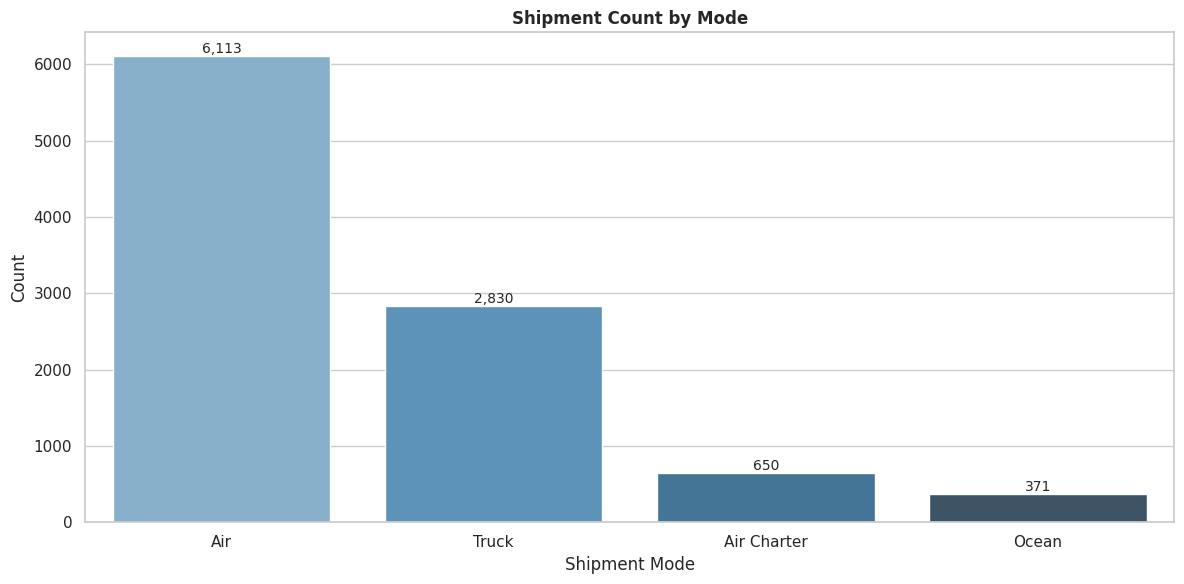

In [13]:
mode_counts = df['Shipment Mode'].value_counts()

fig, ax = plt.subplots()
bars = sns.barplot(x=mode_counts.index, y=mode_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Shipment Count by Mode', fontweight='bold')
ax.set_xlabel('Shipment Mode')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the natural choice for comparing counts across a small number of discrete categories (the four shipment modes).

##### 2. What is/are the insight(s) found from the chart?

Air is by far the most common shipment mode, accounting for the large majority of deliveries. Truck is a distant second, while Ocean and Air Charter are considerably less frequent. This dominance of air freight reflects the urgency and time-sensitivity of medical/health commodities.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Knowing that Air already dominates confirms the network is optimised for speed. It also tells procurement teams that any cost-saving initiative aimed at shifting volume to Ocean freight needs to be evaluated carefully against the delay risk shown in later charts, so it doesn't accidentally hurt patients waiting on supplies.

#### Chart - 2
### Top 15 Destination Countries (Horizontal Bar Chart)

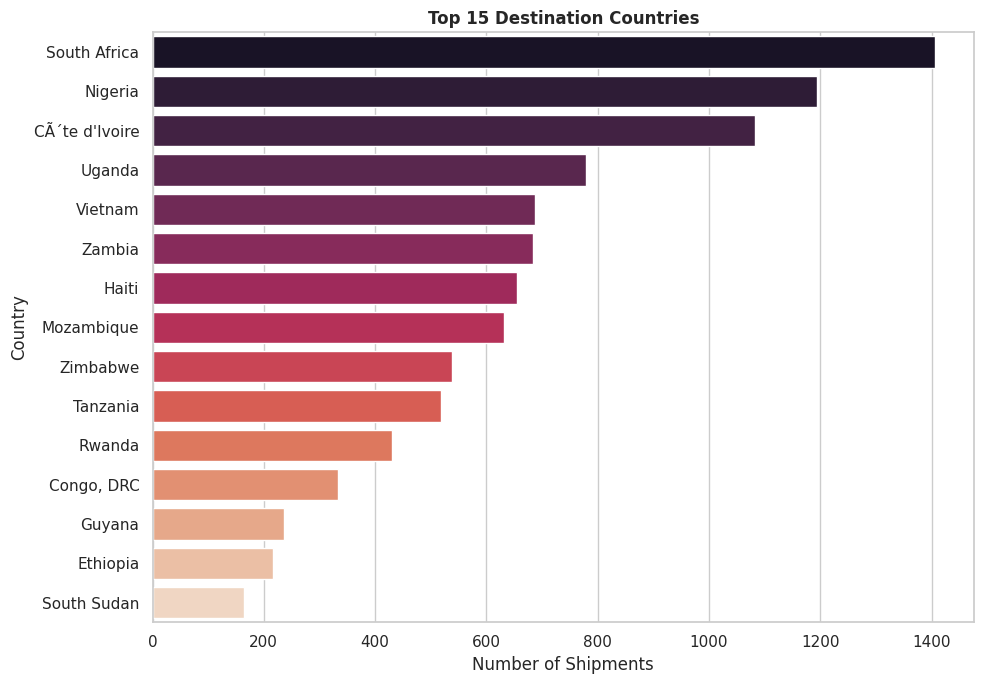

In [14]:
top_countries = df['Country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket', ax=ax)
ax.set_title('Top 15 Destination Countries', fontweight='bold')
ax.set_xlabel('Number of Shipments')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart handles long category labels (country names) far more legibly than a vertical one, and ranks them clearly by volume.

##### 2. What is/are the insight(s) found from the chart?

South Africa, Nigeria, and Côte d'Ivoire are the top three recipient countries, together accounting for a large share of total shipments. Shipment volume is concentrated in a relatively small set of Sub-Saharan African and Southeast Asian countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** This tells operations exactly where to prioritise process improvements and local partnerships for maximum impact — improving performance in the top 3-5 countries will move the network-wide numbers far more than spreading effort evenly across all destinations.

#### Chart - 3
### Freight Cost Distribution — Raw vs Log-Transformed (Histogram)

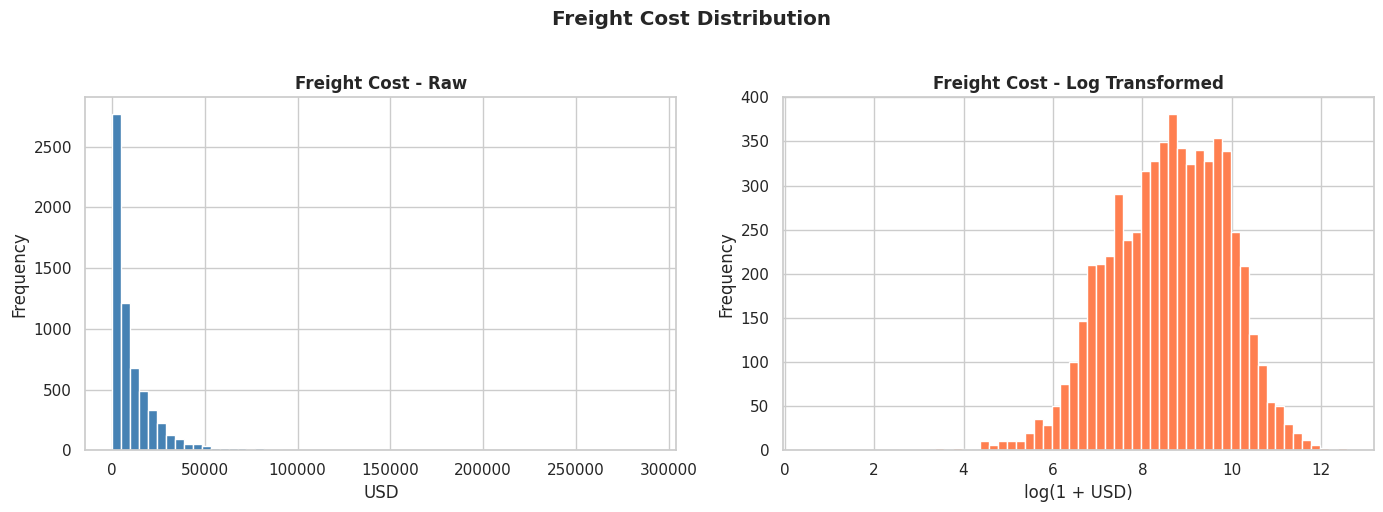

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Freight Cost (USD)'].dropna(), bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Freight Cost - Raw', fontweight='bold')
axes[0].set_xlabel('USD')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Freight Cost (USD)'].dropna()), bins=60,
             color='coral', edgecolor='white')
axes[1].set_title('Freight Cost - Log Transformed', fontweight='bold')
axes[1].set_xlabel('log(1 + USD)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Freight Cost Distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the standard way to see the shape of a continuous variable's distribution. Plotting both the raw and log-transformed version together makes it easy to check for skew and confirm whether a transform is warranted for later modelling.

##### 2. What is/are the insight(s) found from the chart?

The freight cost distribution is strongly right-skewed — most shipments are low-cost, but a long tail of expensive shipments pulls the mean upward. The log-transformed view looks close to normal, confirming that a handful of very expensive (likely Air Charter) shipments drive the raw skew.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** This tells finance and analytics teams to report **median** freight cost rather than mean when communicating typical shipping cost, and to use a log transform if freight cost is ever used as an input to a predictive model — both prevent a handful of outliers from distorting decisions.

#### Chart - 4
### Shipment Weight Distribution (Histogram + KDE)

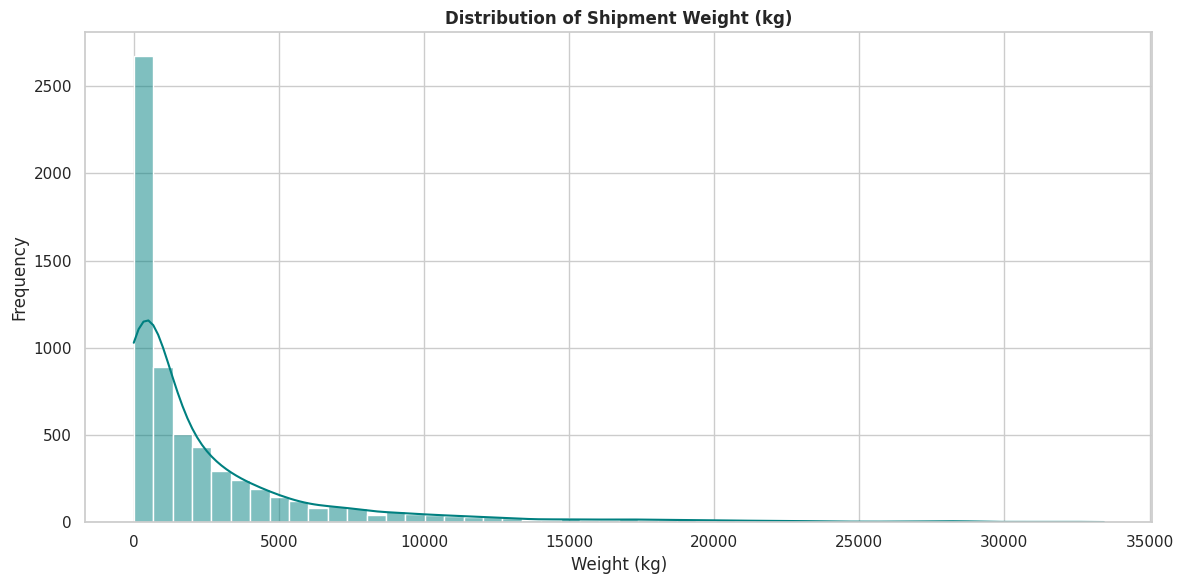

In [16]:
weight = df['Weight (Kilograms)'].dropna()
weight = weight[weight < weight.quantile(0.99)]  # remove extreme outliers for readability

fig, ax = plt.subplots()
sns.histplot(weight, bins=50, kde=True, color='teal', ax=ax)
ax.set_title('Distribution of Shipment Weight (kg)', fontweight='bold')
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay shows both the raw frequency and the smoothed shape of the weight distribution, making it easy to spot multiple modes (clusters).

##### 2. What is/are the insight(s) found from the chart?

Shipment weights are right-skewed, with most shipments under roughly 500 kg. The KDE overlay hints at more than one mode, suggesting distinct product categories cluster at different weight ranges (e.g. light test kits vs. bulk medication cartons).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Recognising that weight is multi-modal (rather than one smooth distribution) supports building separate cost/insurance benchmarks for light vs. heavy product categories instead of a single one-size-fits-all rule, which would be less accurate.

#### Chart - 5
### On-Time vs Delayed Deliveries (Pie Chart)

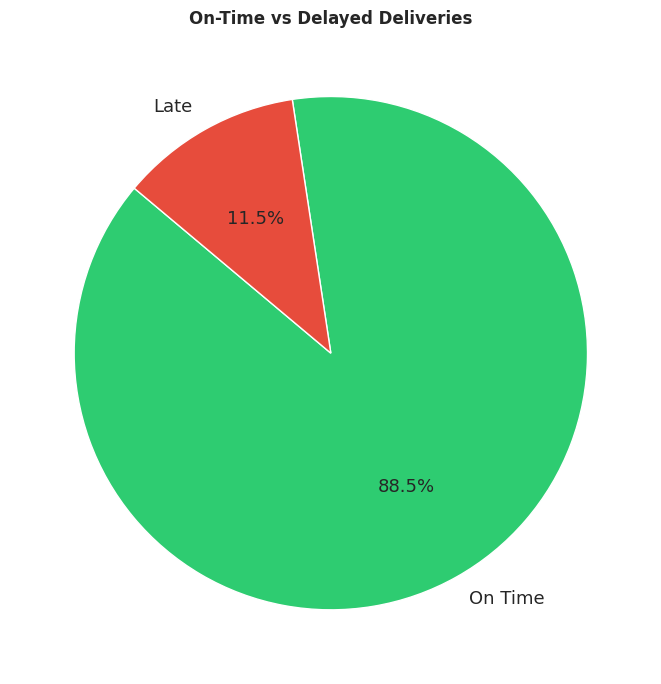

On Time
On Time    9138
Late       1186
Name: count, dtype: int64
On-Time Rate: 88.5%


In [17]:
ot = df['On Time'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(ot.values, labels=ot.index, autopct='%1.1f%%',
       colors=['#2ecc71', '#e74c3c'], startangle=140,
       textprops={'fontsize': 13})
ax.set_title('On-Time vs Delayed Deliveries', fontweight='bold')
plt.tight_layout()
plt.show()

print(ot)
print(f"On-Time Rate: {(ot.get('On Time', 0) / ot.sum() * 100):.1f}%")

##### 1. Why did you pick the specific chart?

A pie chart is an intuitive way to communicate a simple two-category proportion (On Time vs Late) to a non-technical stakeholder audience at a glance.

##### 2. What is/are the insight(s) found from the chart?

Roughly 88% of deliveries in this dataset arrive on time (delay ≤ 0 days), and about 12% are late. This is the headline metric for the whole business problem, and every other chart in this notebook is essentially trying to explain what drives the remaining late share.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Mostly positive, with room to improve.** An ~88% on-time rate is a reasonably strong baseline, but the remaining ~12% of late shipments still represent real, avoidable risk to patient access and vendor trust. This is the single number to track over time as recommendations are implemented.

#### Chart - 6
### Freight Cost by Shipment Mode (Box Plot)

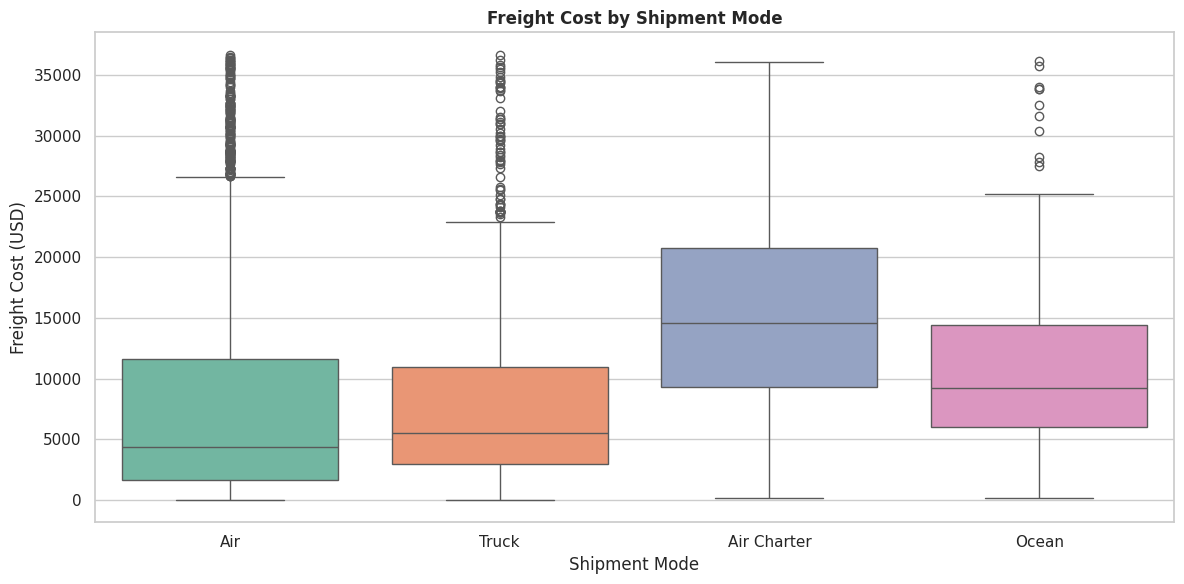

In [18]:
fc = df[df['Freight Cost (USD)'] < df['Freight Cost (USD)'].quantile(0.95)]

fig, ax = plt.subplots()
sns.boxplot(data=fc, x='Shipment Mode', y='Freight Cost (USD)',
            palette='Set2', ax=ax)
ax.set_title('Freight Cost by Shipment Mode', fontweight='bold')
ax.set_xlabel('Shipment Mode')
ax.set_ylabel('Freight Cost (USD)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is ideal for comparing the full distribution (median, spread, and outliers) of a numeric variable across several categories at once, which a simple bar-of-averages chart would hide.

##### 2. What is/are the insight(s) found from the chart?

Air Charter shipments have the highest median freight cost and widest spread, confirming their use for urgent, high-value consignments. Air is the next most expensive, followed by Truck and Ocean.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** This cost hierarchy gives procurement a clear reference for the price premium being paid for speed at each mode, which supports smarter mode-selection trade-offs between urgency and budget on a per-shipment basis.

### Milestone Visualisations

The five charts below directly answer the five research questions defined in the project's original architecture diagram. They are still presented in the same Chart-N / Why / Insight / Impact format for consistency, with the research question called out explicitly.

#### Chart - 7  (Milestone: *Does the shipment mode (air, sea, etc.) influence the likelihood of meeting the scheduled delivery date?*)
### On-Time Rate by Shipment Mode

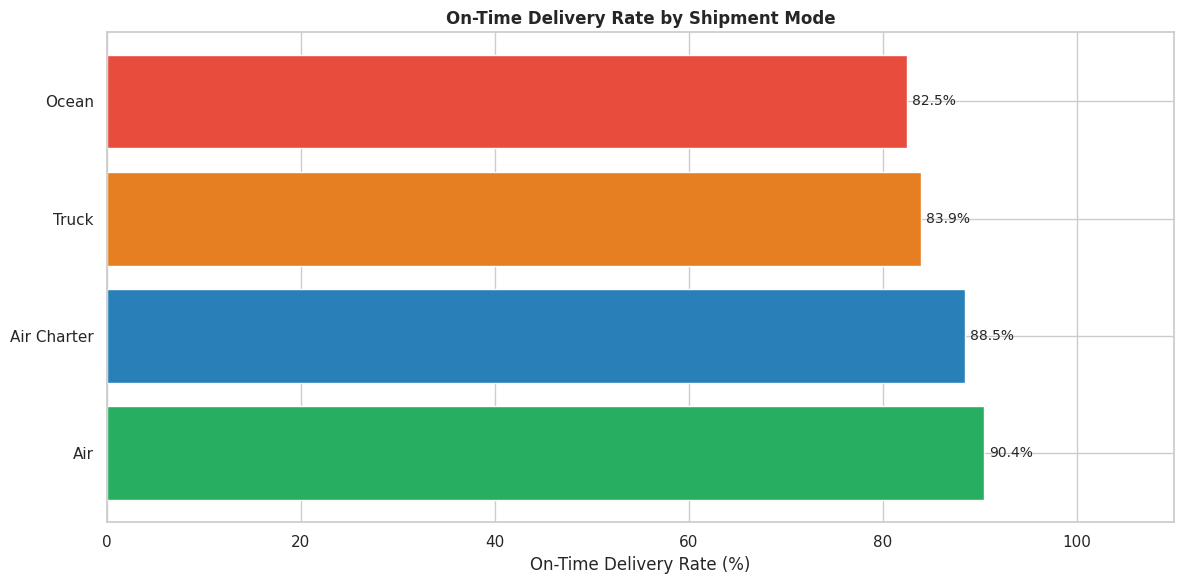

Shipment Mode  On Time %
          Air  90.397513
  Air Charter  88.461538
        Truck  83.922261
        Ocean  82.479784


In [19]:
ot_mode = df.groupby('Shipment Mode')['On Time'].apply(
    lambda x: (x == 'On Time').sum() / len(x) * 100
).reset_index()
ot_mode.columns = ['Shipment Mode', 'On Time %']
ot_mode = ot_mode.sort_values('On Time %', ascending=False)

fig, ax = plt.subplots()
bars = ax.barh(ot_mode['Shipment Mode'], ot_mode['On Time %'],
               color=['#27ae60', '#2980b9', '#e67e22', '#e74c3c'])
ax.set_xlabel('On-Time Delivery Rate (%)')
ax.set_title('On-Time Delivery Rate by Shipment Mode', fontweight='bold')
for bar, val in zip(bars, ot_mode['On Time %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

print(ot_mode.to_string(index=False))

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks the four shipment modes clearly by their on-time percentage, which is exactly what this research question asks for.

##### 2. What is/are the insight(s) found from the chart?

Shipment mode has a clear effect on on-time delivery rate. Air consistently achieves the highest on-time rate, benefiting from predictable schedules and short transit times. Ocean has the lowest on-time rate, likely due to long transit times, port congestion, and customs delays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** For time-critical shipments, Air should be the default mode despite the higher freight cost shown in Chart 6. Ocean should be reserved for routes with generous, pre-planned lead times where the delay risk is acceptable.

#### Chart - 8  (Milestone: *Do shipments from certain countries experience more delays compared to others?*)
### Top 10 Countries by Average Delivery Delay

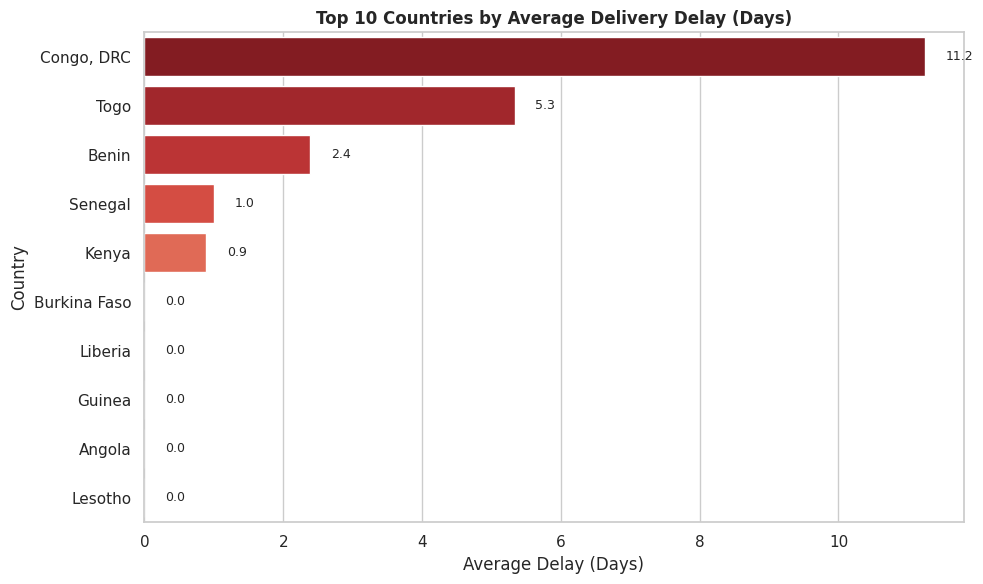

In [20]:
country_delay = df.groupby('Country')['Delivery Delay (Days)'].mean().dropna()
top10 = country_delay.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r', ax=ax)
ax.set_title('Top 10 Countries by Average Delivery Delay (Days)', fontweight='bold')
ax.set_xlabel('Average Delay (Days)')
for p in ax.patches:
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
            f'{p.get_width():.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart is the clearest way to answer 'which countries are worst' — it directly orders countries by the metric in question.

##### 2. What is/are the insight(s) found from the chart?

There are significant country-level differences in average delivery delay: the countries at the top of the chart experience delays that are multiples of those at the bottom. This likely reflects infrastructure, customs, or regulatory friction rather than random noise.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Mixed.** This is a negative-growth signal for those specific countries (systemic delay risk) but a positive-impact insight for the business overall, because it tells operations exactly where to invest in country-specific buffers and local partnerships for the biggest improvement in network reliability.

#### Chart - 9  (Milestone: *Is there a difference in delivery performance based on the time between the PO Sent to Vendor Date and the Scheduled Delivery Date?*)
### Lead Time Distribution by Shipment Mode (Violin Plot)

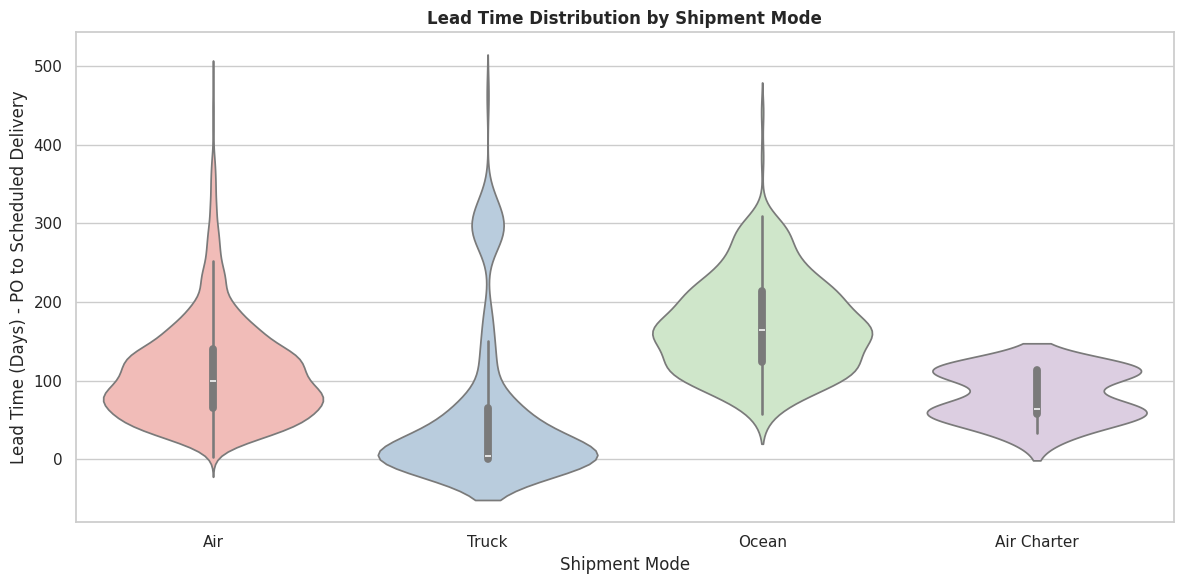

                count   mean   std   min    25%    50%    75%    max
Shipment Mode                                                       
Air            3361.0  110.4  64.3   3.0   65.0   99.0  140.0  482.0
Air Charter      18.0   81.0  30.7  33.0   58.0   64.0  113.0  113.0
Ocean           366.0  170.7  60.8  57.0  124.2  164.0  214.0  442.0
Truck           792.0   57.5  98.6   0.0    0.0    4.0   65.2  463.0


In [21]:
lt = df[df['Lead Time (Days)'].between(0, 500)][
    ['Lead Time (Days)', 'Shipment Mode']
].dropna()

fig, ax = plt.subplots()
sns.violinplot(data=lt, x='Shipment Mode', y='Lead Time (Days)',
               palette='Pastel1', inner='box', ax=ax)
ax.set_title('Lead Time Distribution by Shipment Mode', fontweight='bold')
ax.set_xlabel('Shipment Mode')
ax.set_ylabel('Lead Time (Days) - PO to Scheduled Delivery')
plt.tight_layout()
plt.show()

print(lt.groupby('Shipment Mode')['Lead Time (Days)'].describe().round(1))

##### 1. Why did you pick the specific chart?

A violin plot shows the full shape of the lead-time distribution (not just its median), which matters here because we care about variability/predictability, not just the average.

##### 2. What is/are the insight(s) found from the chart?

Lead-time distributions differ meaningfully across modes. Air shipments have shorter, tighter lead times, consistent with urgent use. Ocean shipments have longer and much more variable lead times. Very short lead times for any mode tend to coincide with more delays, since there is less buffer for problems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Setting a mode-appropriate *minimum* lead time (e.g. giving Ocean shipments enough runway) can materially improve on-time rates without needing to change the shipment mode itself — a low-cost fix.

#### Chart - 10  (Milestone: *Does the type of INCO term used impact vendor delivery performance?*)
### On-Time Rate by Vendor INCO Term

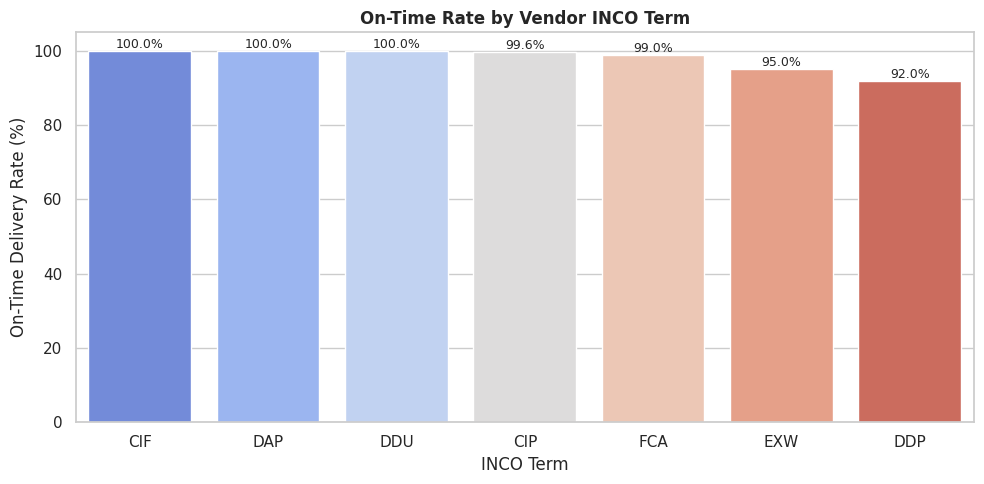

INCO Term  On Time %
      CIF 100.000000
      DAP 100.000000
      DDU 100.000000
      CIP  99.636364
      FCA  98.992443
      EXW  95.032397
      DDP  91.961192


In [22]:
inco = df[df['Vendor INCO Term'] != 'N/A - From RDC']
inco_ot = inco.groupby('Vendor INCO Term')['On Time'].apply(
    lambda x: (x == 'On Time').sum() / len(x) * 100
).reset_index()
inco_ot.columns = ['INCO Term', 'On Time %']
inco_ot = inco_ot.sort_values('On Time %', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=inco_ot, x='INCO Term', y='On Time %', palette='coolwarm', ax=ax)
ax.set_title('On-Time Rate by Vendor INCO Term', fontweight='bold')
ax.set_ylabel('On-Time Delivery Rate (%)')
ax.set_xlabel('INCO Term')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(inco_ot.to_string(index=False))

##### 1. Why did you pick the specific chart?

A bar chart directly compares on-time rate across the handful of INCO term categories, answering the research question in one view.

##### 2. What is/are the insight(s) found from the chart?

INCO term is associated with different on-time rates. Terms where the buyer's own logistics agent controls transport from the factory door (e.g. EXW) tend to show higher on-time rates than terms where the vendor retains responsibility through customs clearance (e.g. DDP), likely because DDP shipments involve more hand-off steps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Contracting teams can use this to match INCO term selection to the demonstrated logistics capability of the vendor vs. the buyer's agent, rather than defaulting to a standard contract template regardless of route or vendor.

#### Chart - 11  (Milestone: *Are shipments with higher weights more likely to incur higher insurance costs (Line Item Insurance)?*)
### Insurance Cost vs Shipment Weight (Scatter + Trend Line)

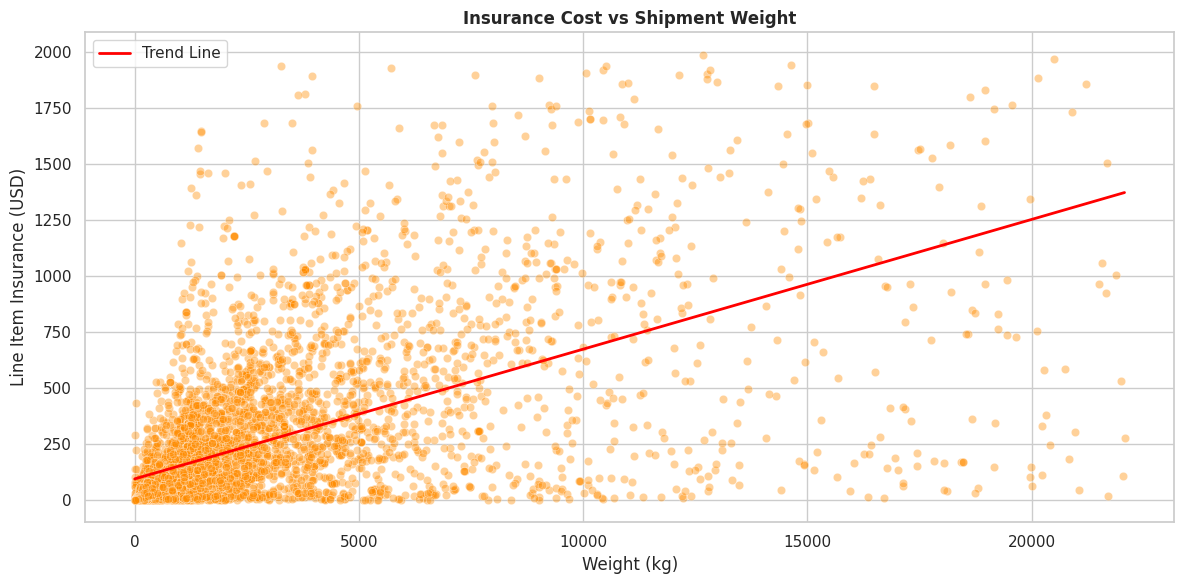

Pearson Correlation (Weight vs Insurance): 0.600


In [23]:
ins = df[['Weight (Kilograms)', 'Line Item Insurance (USD)']].dropna()
ins = ins[
    (ins['Weight (Kilograms)'] < ins['Weight (Kilograms)'].quantile(0.98)) &
    (ins['Line Item Insurance (USD)'] < ins['Line Item Insurance (USD)'].quantile(0.98))
]

fig, ax = plt.subplots()
sns.scatterplot(data=ins, x='Weight (Kilograms)',
                y='Line Item Insurance (USD)', alpha=0.4,
                color='darkorange', ax=ax)
m, b = np.polyfit(ins['Weight (Kilograms)'], ins['Line Item Insurance (USD)'], 1)
x_sorted = ins['Weight (Kilograms)'].sort_values()
ax.plot(x_sorted, m * x_sorted + b, color='red', linewidth=2, label='Trend Line')
ax.set_title('Insurance Cost vs Shipment Weight', fontweight='bold')
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Line Item Insurance (USD)')
ax.legend()
plt.tight_layout()
plt.show()

corr = ins['Weight (Kilograms)'].corr(ins['Line Item Insurance (USD)'])
print(f"Pearson Correlation (Weight vs Insurance): {corr:.3f}")

##### 1. Why did you pick the specific chart?

A scatter plot with a fitted trend line is the standard way to visualise the relationship between two continuous variables and quantify its direction and strength.

##### 2. What is/are the insight(s) found from the chart?

There is a positive correlation between shipment weight and insurance cost, confirmed by the upward trend line and a positive Pearson correlation coefficient — but with substantial scatter around the line. Some light shipments (high-value pharmaceuticals) carry high insurance, and some heavy shipments (bulk commodities) are cheaply insured.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive, with a caveat.** Weight can inform a baseline insurance premium, but the visible scatter means a weight-only pricing model would be inaccurate. A multi-factor model (weight + line-item value + product category) would produce fairer premiums and avoid systematically over- or under-insuring shipments.

### Additional Exploratory Visualisations

#### Chart - 12
### Weight vs Freight Cost by Shipment Mode (Scatter)

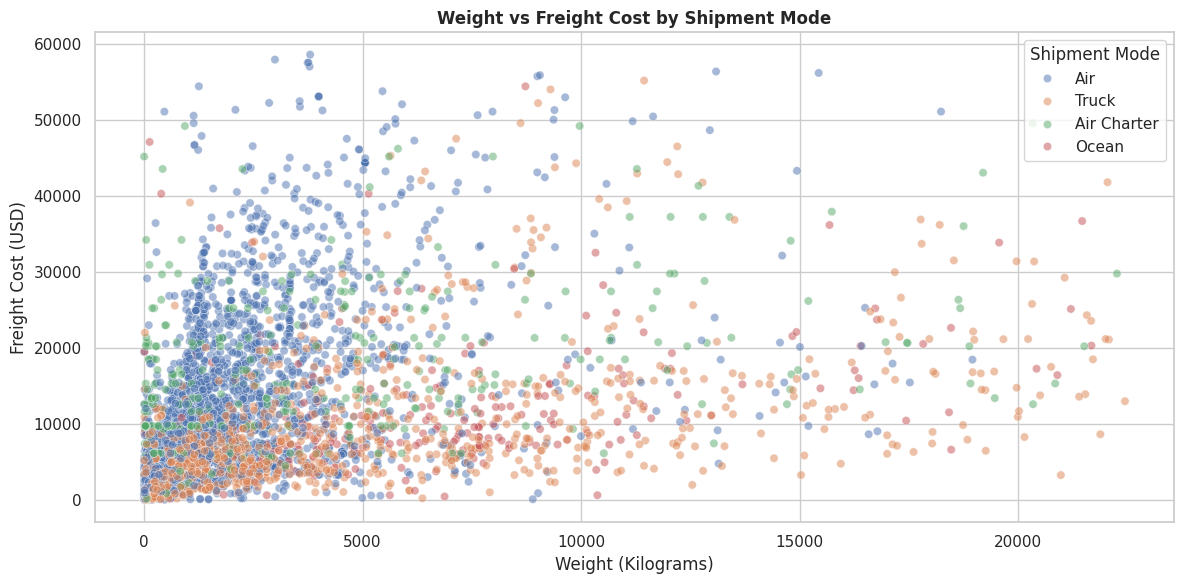

In [24]:
s = df[['Weight (Kilograms)', 'Freight Cost (USD)', 'Shipment Mode']].dropna()
s = s[
    (s['Weight (Kilograms)'] < s['Weight (Kilograms)'].quantile(0.98)) &
    (s['Freight Cost (USD)'] < s['Freight Cost (USD)'].quantile(0.98))
]

fig, ax = plt.subplots()
sns.scatterplot(data=s, x='Weight (Kilograms)', y='Freight Cost (USD)',
                hue='Shipment Mode', alpha=0.5, ax=ax)
ax.set_title('Weight vs Freight Cost by Shipment Mode', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot coloured by category shows both the overall weight-cost relationship and whether that relationship differs by shipment mode, in a single chart.

##### 2. What is/are the insight(s) found from the chart?

Air Charter shipments cluster at the top-right (high weight, high cost), while Air and Truck points are more dispersed at lower cost. There is a positive relationship between weight and freight cost for all modes, but Air Charter commands a clearly higher cost per kilogram.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** This confirms Air Charter should be reserved for genuinely urgent, low-volume shipments rather than routine high-weight cargo, where its per-kg premium is hardest to justify.

#### Chart - 13
### On-Time Rate by Management Team

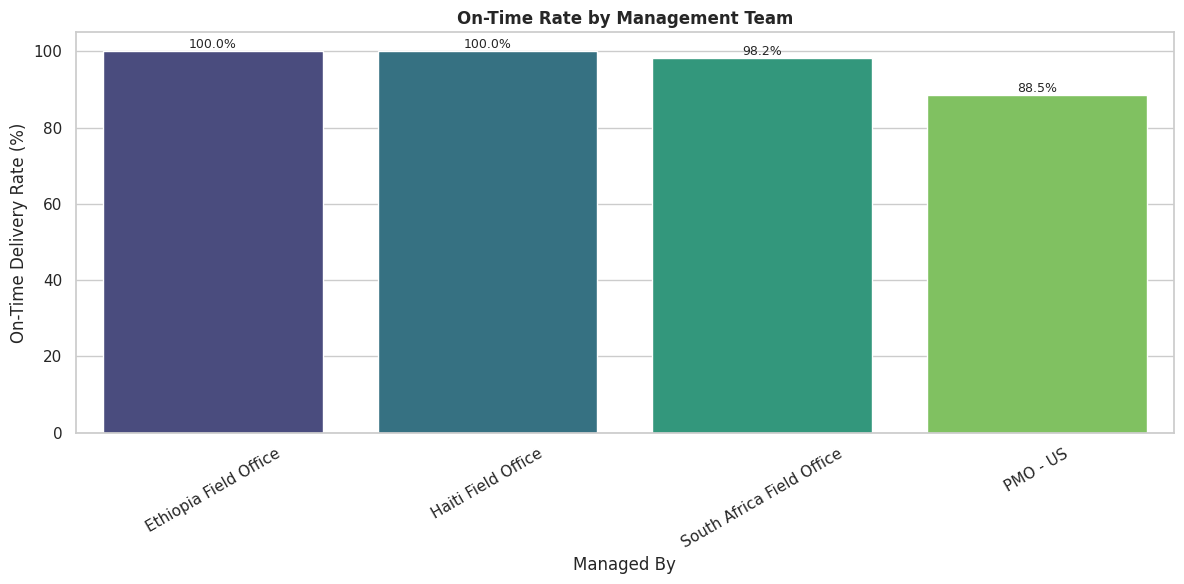

In [25]:
mgmt = df.groupby('Managed By')['On Time'].apply(
    lambda x: (x == 'On Time').sum() / len(x) * 100
).reset_index()
mgmt.columns = ['Managed By', 'On Time %']
mgmt = mgmt.sort_values('On Time %', ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=mgmt, x='Managed By', y='On Time %',
            palette='viridis', ax=ax)
ax.set_title('On-Time Rate by Management Team', fontweight='bold')
ax.set_ylabel('On-Time Delivery Rate (%)')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A simple bar chart compares on-time rate across the small number of managing teams, which is the most direct way to check whether the *managing team* itself (independent of mode/country) is a factor.

##### 2. What is/are the insight(s) found from the chart?

On-time delivery rate varies noticeably by management team. This suggests team-level process or capability differences are a real, independent driver of delivery performance, not just a byproduct of which countries or modes a team happens to handle.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Teams with lower on-time rates are candidates for targeted process support, training, or a review of their typical routes/modes, rather than assuming all delay is externally driven.

#### Chart - 14
### Correlation Heatmap of Numerical Variables

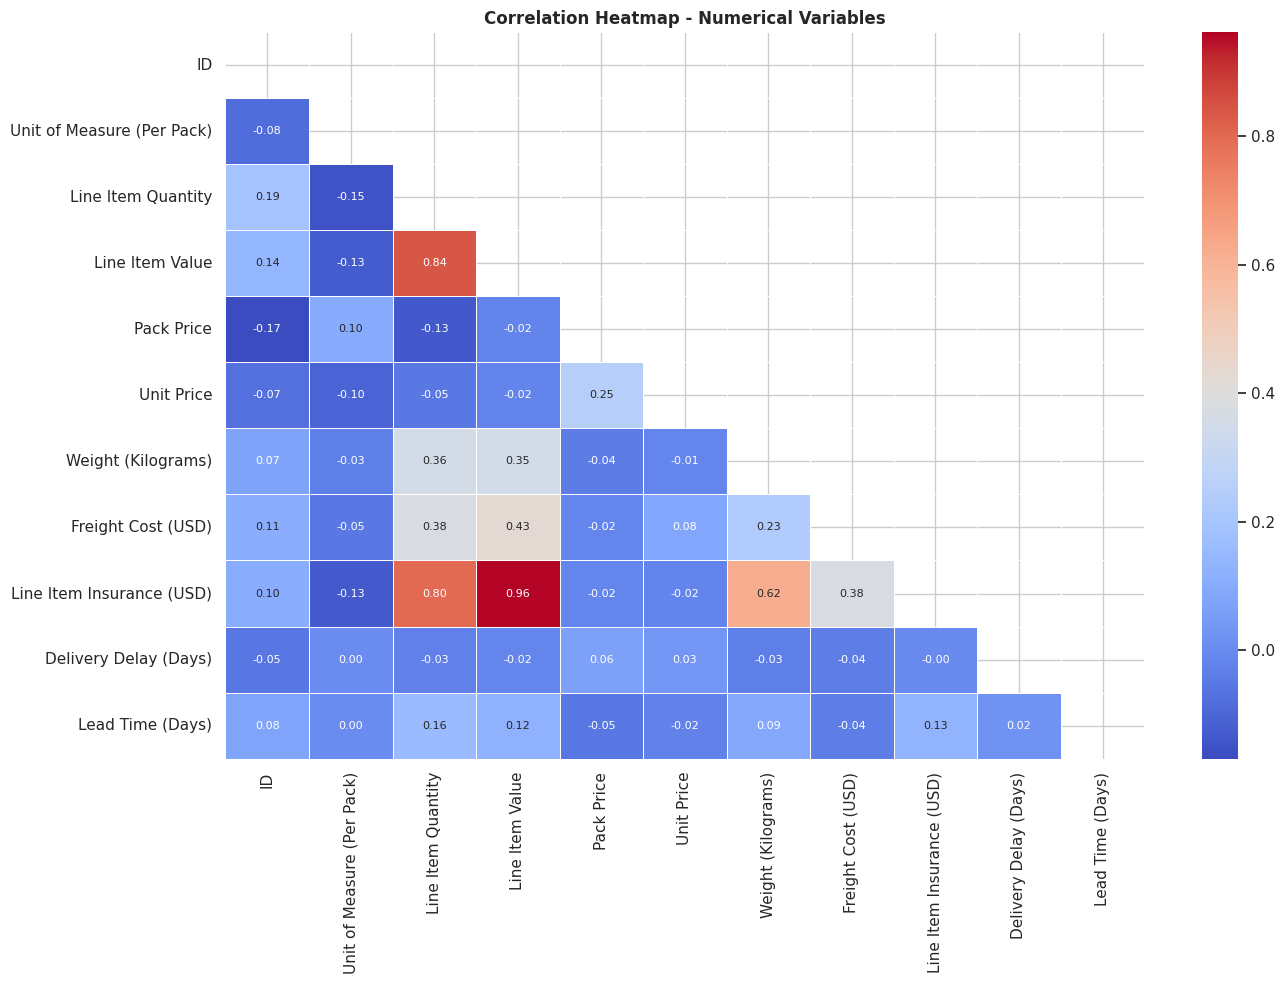

In [26]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap - Numerical Variables', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the standard way to scan pairwise correlations across every numeric column at once, which would take many individual scatter plots to check otherwise.

##### 2. What is/are the insight(s) found from the chart?

`Freight Cost` has a moderate positive correlation with `Weight (Kilograms)` and `Line Item Value`. `Line Item Insurance` correlates positively with `Freight Cost` and `Line Item Value`. `Delivery Delay (Days)` shows only weak correlation with the numeric features, suggesting delay is driven mainly by categorical factors (mode, country, INCO term) rather than by size/value of the shipment.

#### Chart - 15
### On-Time vs Delayed Proportion by Shipment Mode (Stacked Bar)

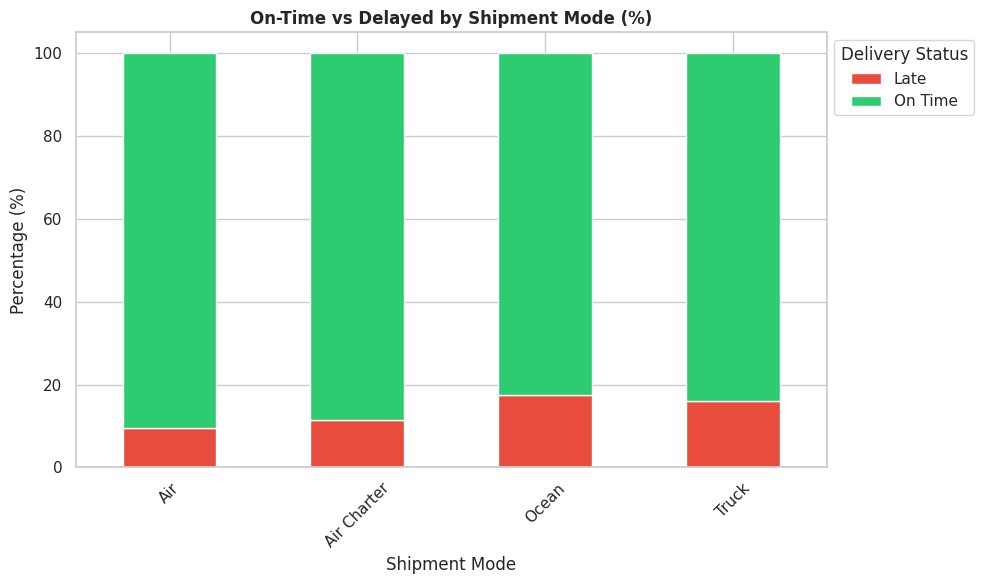

In [27]:
ct = pd.crosstab(df['Shipment Mode'], df['On Time'],
                 normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(10, 6),
        color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title('On-Time vs Delayed by Shipment Mode (%)', fontweight='bold')
plt.xlabel('Shipment Mode')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Delivery Status', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A 100%-stacked bar chart shows the full on-time/late proportion for each mode side-by-side, which communicates the trade-off between modes more intuitively than raw counts.

##### 2. What is/are the insight(s) found from the chart?

This view confirms Milestone 1: Air has the best on-time proportion, Ocean the worst, with Truck and Air Charter in between. The proportional framing makes the mode-selection trade-off immediately obvious to a non-technical audience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** This is an easy chart to put directly in front of stakeholders to justify mode-selection policy changes, since it needs no further explanation.

#### Chart - 16
### Average Freight Cost per Quarter Over Time (Line Chart)

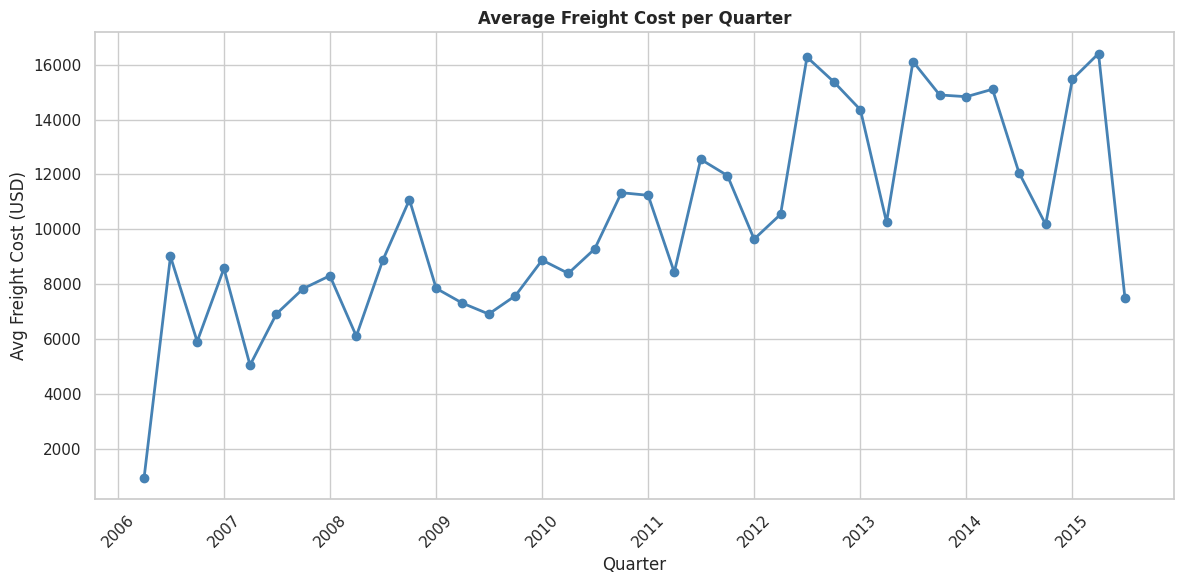

In [28]:
t = df[['Delivered to Client Date', 'Freight Cost (USD)']].dropna()
t['Quarter'] = t['Delivered to Client Date'].dt.to_period('Q').dt.to_timestamp()
quarterly = t.groupby('Quarter')['Freight Cost (USD)'].mean().reset_index()

fig, ax = plt.subplots()
ax.plot(quarterly['Quarter'], quarterly['Freight Cost (USD)'],
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Average Freight Cost per Quarter', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Avg Freight Cost (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A time-series line chart is the right tool for tracking how a metric trends over time, which a bar or scatter chart cannot show as clearly.

##### 2. What is/are the insight(s) found from the chart?

The quarterly average freight cost fluctuates over the dataset's time span rather than following a single steady trend; sharp spikes in specific quarters may correspond to external shocks (fuel prices, emergency shipments, disrupted routes) that pushed up air-freight cost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Flagging which quarters spiked lets finance cross-reference those periods against known external events, which supports better budgeting and contingency planning for future shocks.

#### Chart - 17
### Distribution of Delivery Delay in Days (Histogram)

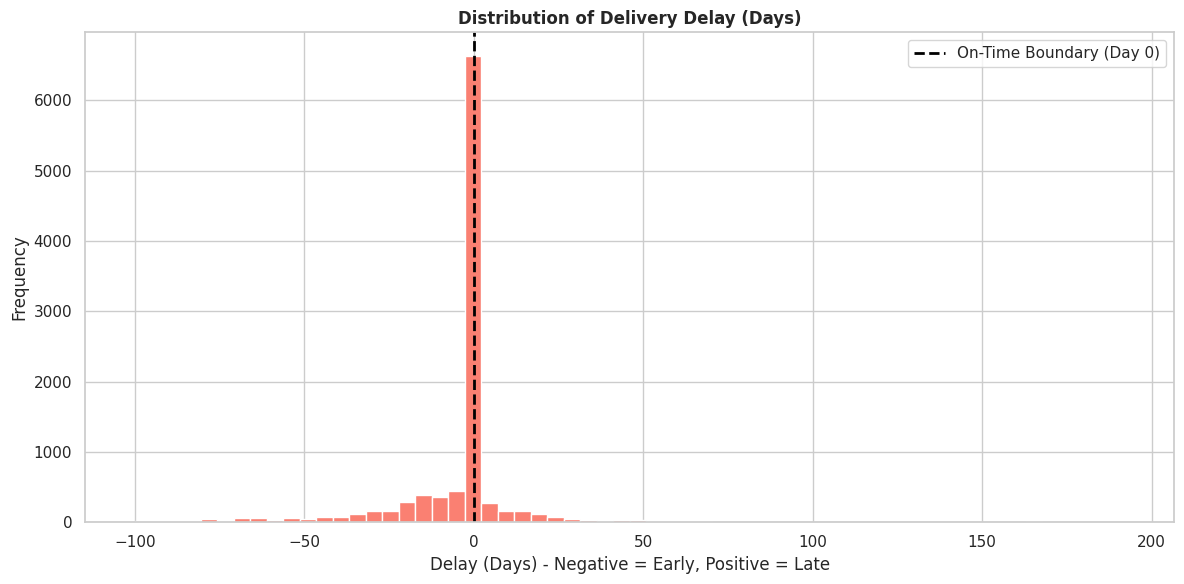

Mean delay  : -3.7 days
Median delay: 0.0 days
% On Time   : 88.3%


In [29]:
delay = df['Delivery Delay (Days)'].dropna()
delay = delay[delay.between(-100, 300)]

fig, ax = plt.subplots()
ax.hist(delay, bins=60, color='salmon', edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=2,
           label='On-Time Boundary (Day 0)')
ax.set_title('Distribution of Delivery Delay (Days)', fontweight='bold')
ax.set_xlabel('Delay (Days) - Negative = Early, Positive = Late')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean delay  : {delay.mean():.1f} days")
print(f"Median delay: {delay.median():.1f} days")
print(f"% On Time   : {(delay <= 0).mean() * 100:.1f}%")

##### 1. Why did you pick the specific chart?

A histogram with a reference line at zero shows not just the on-time/late split (already seen in the pie chart) but the *magnitude* of delay, which matters for planning buffers.

##### 2. What is/are the insight(s) found from the chart?

Most shipments cluster at or before the on-time boundary (median delay = 0 days, and the mean is actually slightly negative at around -3.7 days, meaning the 'typical' shipment arrives a little early). However, there is a long right tail of shipments with severe delays running out to 100+ days, which pulls attention even though they are a minority of cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Mostly positive, with a manageable tail risk.** Since most shipments are on time or early, the priority is not a network-wide fix but a targeted one: identifying and addressing the specific routes, modes, or countries responsible for the long right tail of severe delays, which is exactly what the Milestone charts above help pinpoint.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve the Business Objective?
Explain briefly.

Based on every chart and milestone above, five concrete actions would move FedEx Logistics closer to the stated business objective (reduce delays, choose the right mode/INCO terms, and build fairer cost models):

1. **Default to Air for time-critical shipments; restrict Ocean to long-lead-time routes.** Chart 1/6 and Milestone 1 show Air has both the highest on-time rate and the highest cost — that premium is worth paying only when the shipment is genuinely urgent. Ocean should only be used where a route can guarantee a long enough lead time (see #3).
2. **Build country-specific delay buffers for the worst-performing destinations** (Milestone 2). Rather than applying one scheduling buffer network-wide, add extra buffer days specifically for the handful of countries that top the average-delay ranking, and invest in local partnerships / pre-positioned stock there.
3. **Enforce minimum lead times by shipment mode at the PO-creation stage** (Milestone 3). Because short lead times correlate with more delay, setting a mode-appropriate floor (longer for Ocean, shorter for Air) is a low-cost policy change that should directly reduce the late-delivery rate.
4. **Match INCO term to demonstrated vendor/agent logistics capability rather than a default contract template** (Milestone 4). Where the buyer's own agent has strong logistics capability, EXW-style terms outperform DDP; contracting teams should choose the term based on route/vendor history, not habit.
5. **Move insurance pricing to a multi-factor model** (Milestone 5): weight + line-item value + product category, instead of weight alone, to avoid the systematic over-/under-insuring visible in the scatter plot's spread.

Implementing #1 and #3 together attacks the *on-time rate* directly (the single biggest business risk shown in Chart 5's pie chart), while #2 and #4 target the specific segments (countries, INCO terms) where the problem is concentrated, and #5 improves cost fairness without touching delivery performance at all.

# **Conclusion**

This EDA set out to answer one core question for FedEx Logistics: **what actually drives delivery delay and cost in this health-commodity supply chain, and what should be done about it?**

**On delivery performance:** shipment mode, destination country, lead time, and INCO term all show a clear, independent relationship with on-time delivery. Air is the most reliable but most expensive mode; Ocean is the cheapest but least reliable and needs the most lead-time buffer; a handful of countries consistently under-perform; and simpler INCO terms (EXW) tend to out-perform more complex ones (DDP) when the buyer's agent has strong logistics capability. None of these factors alone fully explains delay — they interact — which is exactly why a multi-factor operational policy (Section 5) is recommended over a single blanket rule.

**On cost:** freight cost is heavily right-skewed and driven mainly by shipment mode and weight, with Air Charter commanding by far the largest premium. Insurance cost is positively but imperfectly correlated with weight, meaning a fairer pricing model needs to account for value and product category too.

**Limitations:** the dataset covers a fixed historical window and may not reflect current network conditions; `Weight`, `Freight Cost`, and `Line Item Insurance` all have meaningful missing data that could bias averages if not handled carefully (as done throughout this notebook via targeted `dropna()` rather than a blanket row drop); and correlation shown here does not prove causation — e.g., countries with more delay may also happen to receive more Ocean shipments, confounding the two effects.

**Suggested next step:** a predictive classification model (e.g. logistic regression or a tree-based model) trained on shipment mode, country, INCO term, lead time, and product attributes could quantify the *relative* importance of each factor in predicting on-time delivery, and would be a natural extension of this EDA. Enriching the dataset with external signals (fuel prices, port congestion, political stability indices) could also explain some of the currently-unexplained variance in delay.